# Skilling Experiment 1: Titanic Survival EDA
**Course Outcome:** CO1  
**Dataset:** Titanic  
**Environment:** VS Code Jupyter

In [11]:
# Cell 1 — Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

In [12]:
# Cell 2 — Load the dataset
titanic = sns.load_dataset("titanic")
print(titanic.shape)
titanic.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
# Cell 3 — Structure of the data
titanic.info()
print("\nNumeric Summary:")
display(titanic.describe())
print("\nClass balance (Survived):")
titanic["survived"].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

Numeric Summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Class balance (Survived):


survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [14]:
# Cell 4 — Count the missing values as percentages (Group A1)
missing_pct = (titanic.isnull().sum() / len(titanic) * 100).round(1).sort_values(ascending=False)
missing_pct[missing_pct > 0]

deck           77.2
age            19.9
embarked        0.2
embark_town     0.2
dtype: float64

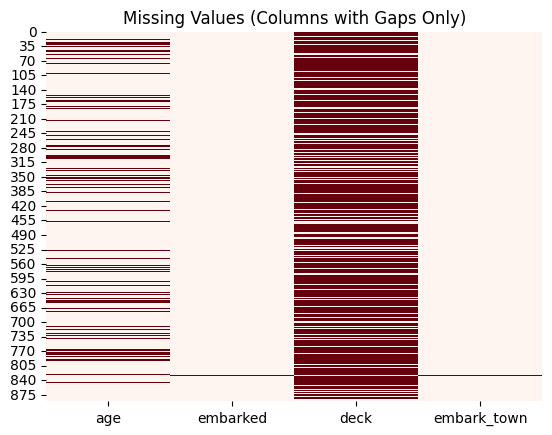

In [15]:
# Cell 5 — Where the values are missing (Group A2: columns with gaps only)
cols_with_missing = titanic.columns[titanic.isnull().any()]
sns.heatmap(titanic[cols_with_missing].isnull(), cbar=False, cmap="Reds")
plt.title("Missing Values (Columns with Gaps Only)")
plt.show()

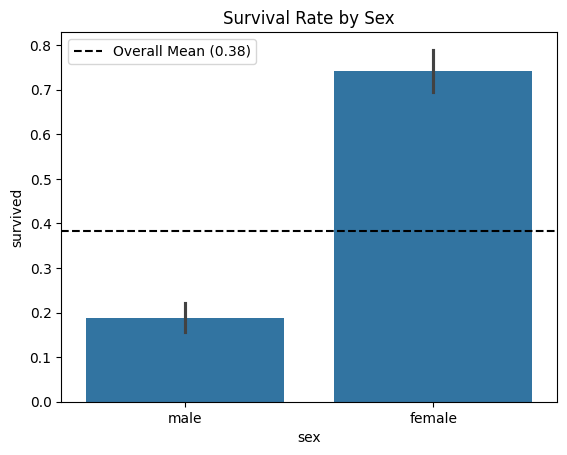

In [16]:
# Cell 6 — Survival rate by sex with reference line (Group B3)
sns.barplot(data=titanic, x="sex", y="survived")
plt.axhline(titanic["survived"].mean(), color="black", linestyle="--", label=f"Overall Mean ({titanic['survived'].mean():.2f})")
plt.title("Survival Rate by Sex")
plt.legend()
plt.show()

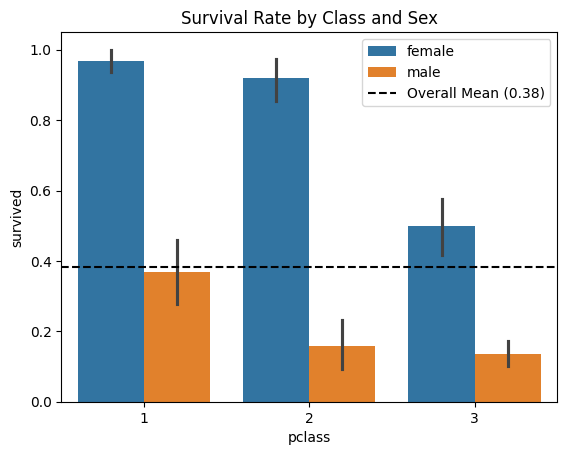

In [17]:
# Cell 7 — Survival rate by class and sex with reference line (Group B4)
sns.barplot(data=titanic, x="pclass", y="survived", hue="sex")
plt.axhline(titanic["survived"].mean(), color="black", linestyle="--", label=f"Overall Mean ({titanic['survived'].mean():.2f})")
plt.title("Survival Rate by Class and Sex")
plt.legend()
plt.show()

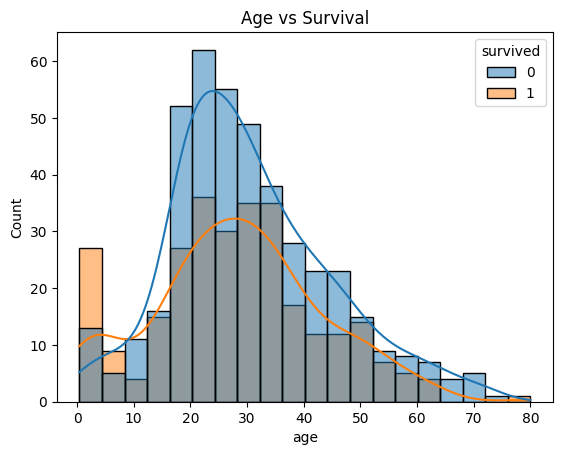

In [18]:
# Cell 8 — Age distribution split by survival
sns.histplot(data=titanic, x="age", hue="survived", kde=True)
plt.title("Age vs Survival")
plt.show()

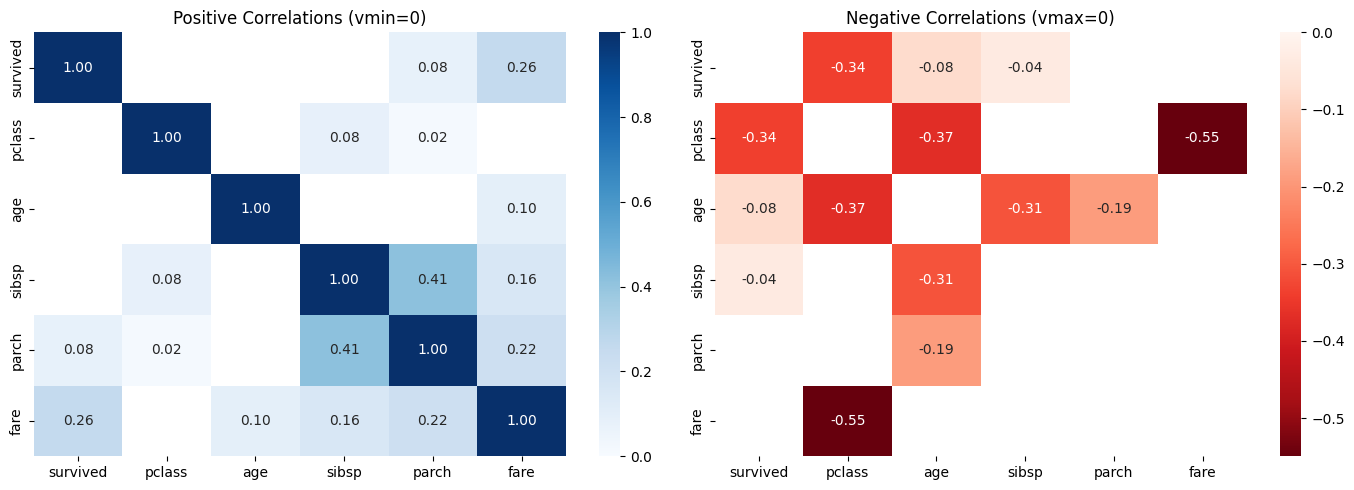

In [19]:
# Cell 9 — Correlation heatmaps: Positive and Negative (Group C5)
cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
cols = [c.strip() for c in cols]
corr = titanic[cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr[corr > 0], annot=True, fmt=".2f", cmap="Blues", vmin=0, ax=axes[0], cbar=True)
axes[0].set_title("Positive Correlations (vmin=0)")

sns.heatmap(corr[corr < 0], annot=True, fmt=".2f", cmap="Reds_r", vmax=0, ax=axes[1], cbar=True)
axes[1].set_title("Negative Correlations (vmax=0)")

plt.tight_layout()
plt.show()

In [20]:
# Cell 10 / Deliverable Function — titanic_eda_report with Findings Page (Group D6)
def titanic_eda_report(df, path="titanic_eda_report.pdf"):
    pdf = PdfPages(path)
    
    # Page 1 - missing values
    plt.figure(figsize=(11, 6))
    cols_with_missing = df.columns[df.isnull().any()]
    sns.heatmap(df[cols_with_missing].isnull(), cbar=False, cmap="Reds")
    plt.title("Page 1 - Missing Values (Gaps Only)")
    pdf.savefig()
    plt.close()
    
    # Page 2 - survival by sex and class
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    overall_avg = df["survived"].mean()
    
    sns.barplot(data=df, x="sex", y="survived", ax=axes[0])
    axes[0].axhline(overall_avg, color="black", linestyle="--", label="Overall Mean")
    axes[0].set_title("Page 2 - Survival Rate by Sex")
    axes[0].legend()
    
    sns.barplot(data=df, x="pclass", y="survived", hue="sex", ax=axes[1])
    axes[1].axhline(overall_avg, color="black", linestyle="--", label="Overall Mean")
    axes[1].set_title("Page 2 - Survival Rate by Class & Sex")
    axes[1].legend()
    
    plt.suptitle("Page 2 - Survival Analysis")
    pdf.savefig()
    plt.close()
    
    # Page 3 - correlation
    cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
    corr = df[cols].corr()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(corr[corr > 0], annot=True, fmt=".2f", cmap="Blues", vmin=0, ax=axes[0])
    axes[0].set_title("Positive Correlations")
    sns.heatmap(corr[corr < 0], annot=True, fmt=".2f", cmap="Reds_r", vmax=0, ax=axes[1])
    axes[1].set_title("Negative Correlations")
    plt.suptitle("Page 3 - Correlation Heatmaps")
    pdf.savefig()
    plt.close()
    
    # Page 4 - findings page (Group D6)
    plt.figure(figsize=(11, 6))
    plt.axis("off")
    plt.text(0.02, 0.94, "Page 4 - Quantitative Findings", size=16, weight="bold")
    
    findings = [
        "1. Missingness: deck is missing 77.2% of data (688 rows), age is missing 19.9% (177 rows), embarked 0.2% (2 rows).",
        "2. Gender Disparity: 74.2% of female passengers survived compared to only 18.9% of male passengers.",
        "3. Class Hierarchy: 1st class survival rate is 63.0%, 2nd class is 47.3%, and 3rd class is 24.2%.",
        "4. Class & Sex Interaction: 3rd-class women (50.0% survival) fared better than 1st-class men (36.9% survival).",
        "5. Key Correlations: Survival correlates negatively with pclass (-0.34) and positively with fare (+0.26). SibSp and Parch correlate (+0.41)."
    ]
    
    y = 0.82
    for line in findings:
        plt.text(0.04, y, line, size=11)
        y -= 0.12
        
    pdf.savefig()
    plt.close()
    pdf.close()
    print("Report written to", path)

titanic_eda_report(titanic)

Report written to titanic_eda_report.pdf
